In [3]:
from sklearn.datasets import fetch_openml
X,y=fetch_openml('titanic', version=1, as_frame=True, return_X_y=True, parser='auto')

In [4]:
print(X.head())
print(X.tail())
print(X.sample(n=5))

   pclass                                             name     sex      age  \
0       1                    Allen, Miss. Elisabeth Walton  female  29.0000   
1       1                   Allison, Master. Hudson Trevor    male   0.9167   
2       1                     Allison, Miss. Helen Loraine  female   2.0000   
3       1             Allison, Mr. Hudson Joshua Creighton    male  30.0000   
4       1  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female  25.0000   

   sibsp  parch  ticket      fare    cabin embarked boat   body  \
0      0      0   24160  211.3375       B5        S    2    NaN   
1      1      2  113781  151.5500  C22 C26        S   11    NaN   
2      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  
0                     St Louis, MO  
1  Montreal, PQ / Chesterville, ON  
2  Montreal

In [5]:
print(X.describe())
print(X.describe(include='object'))
print(X.describe(include='category'))

            pclass          age        sibsp        parch         fare  \
count  1309.000000  1046.000000  1309.000000  1309.000000  1308.000000   
mean      2.294882    29.881135     0.498854     0.385027    33.295479   
std       0.837836    14.413500     1.041658     0.865560    51.758668   
min       1.000000     0.166700     0.000000     0.000000     0.000000   
25%       2.000000    21.000000     0.000000     0.000000     7.895800   
50%       3.000000    28.000000     0.000000     0.000000    14.454200   
75%       3.000000    39.000000     1.000000     0.000000    31.275000   
max       3.000000    80.000000     8.000000     9.000000   512.329200   

             body  
count  121.000000  
mean   160.809917  
std     97.696922  
min      1.000000  
25%     72.000000  
50%    155.000000  
75%    256.000000  
max    328.000000  
                        name    ticket        cabin boat     home.dest
count                   1309      1309          295  486           745
unique     

C:\Users\DS\AppData\Local\Temp\ipykernel_9320\1067660449.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.describe(include='object'))


In [7]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 11.2 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.1 MB 10.7 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 9.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 11.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.0 MB 12.2 MB/s eta 0:00:01
   -------------------------- ------------- 4.7/7.0 MB 11.9 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.0 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 11.1 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pil

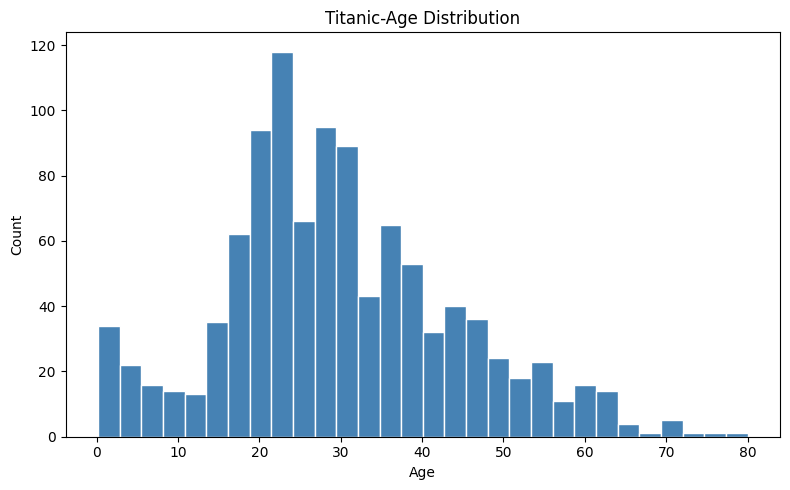

In [8]:
import matplotlib.pyplot as plt

age_data=X['age'].dropna()
plt.figure(figsize=(8,5))
plt.hist(age_data, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Titanic-Age Distribution')
plt.tight_layout()
plt.show()

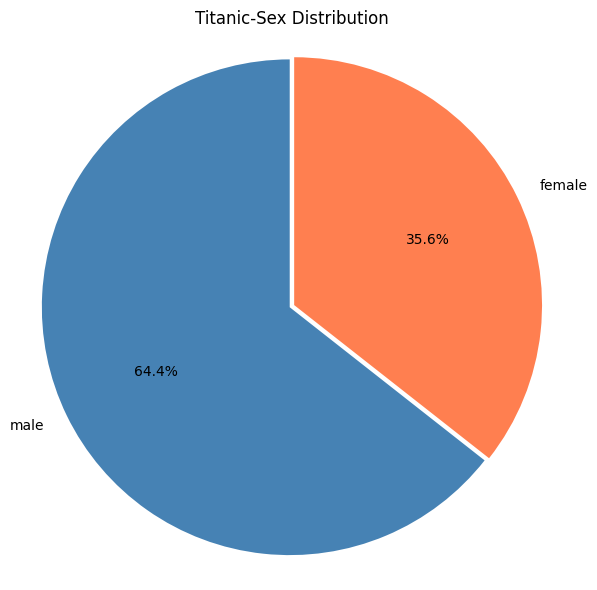

In [13]:
import matplotlib.pyplot as plt

sex_counts=X['sex'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, colors=['steelblue', 'coral'], explode=(0.02,0))
plt.title('Titanic-Sex Distribution')
plt.axis('equal')
plt.tight_layout()
plt.show()

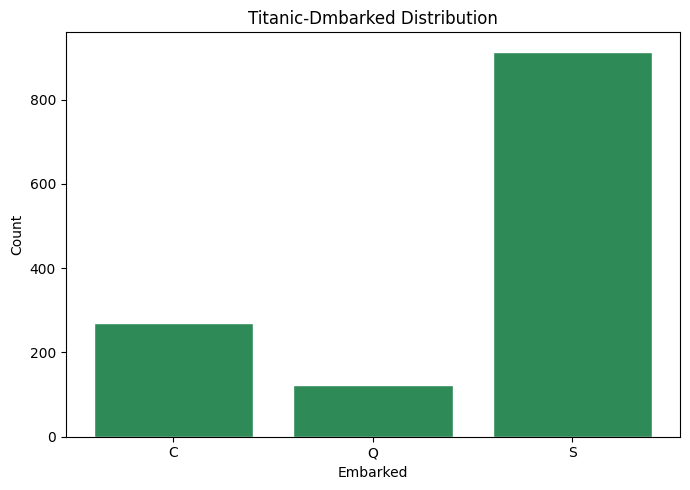

In [ ]:
embarked_counts=X['embarked'].value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.bar(embarked_counts.index.astype(str), embarked_counts.values, color='seagreen', edgecolor='white')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.title('Titanic-Embarked Distribution')
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import numpy as np
from scipy.stats import variation

cols=['pclass','age','sibsp','parch','fare']
stats=[]

for col in cols:
    s=X[col].dropna()
    median_val=s.median()
    mode_val=s.mode().iloc[0]
    mean_val=s.mean()
    cv=variation(s)*100
    stats.append({
        'Variable':col,
        'Median': median_val,
        'Mode': mode_val,
        'CV(%)':round(cv,2)
    })

df_stats=pd.DataFrame(stats)
print(df_stats)

  Variable   Median   Mode   CV(%)
0   pclass   3.0000   3.00   36.49
1      age  28.0000  24.00   48.21
2    sibsp   0.0000   0.00  208.73
3    parch   0.0000   0.00  224.72
4     fare  14.4542   8.05  155.39
